# Information Retrieval Project 2026: Antique Search Engine

The dataset used within the notebook is Antique, because it gives us a realistic retrieval setting with documents, queries, and relevance judgments. 

### IR project agenda

1. Load the Antique dataset for a realistic retrieval experiment.
2. Build a transparent text preprocessing pipeline.
3. Construct an inverted index with document identifiers, term frequencies, document lengths, and collection statistics.
4. Add optional delta and Variable-Byte compression helpers.
5. Implement query processing with TF-IDF and BM25.
6. Compare TAAT and DAAT retrieval styles.
7. Evaluate runs with `ir_measures` using Antique relevance judgments.
8. Add small differentiating experiments, such as query term coverage scoring and optional PyTerrier baselines.


## Setup


In [43]:
# Uncomment if the environment is missing dependencies

!pip install -q ir_datasets ir-measures nltk pandas numpy matplotlib seaborn tqdm python-terrier


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Imports
All the tools we need for the notebook.

* `math` : used for formulas such as logarithms in TF-IDF and BM25.
* `re` : used for regular expressions during text preprocessing.
* `string`: used to access punctuation characters, for example when removing punctuation from text.
* `time` : used to measure runtime for indexing and query processing.
* `heapq` : used to maintain a small top-k priority queue efficiently.
* `Counter` counts term frequencies in a document.
* `defaultdict` creates dictionaries with automatic default values, useful for accumulators and posting lists.
* `Path` : used later for saving output files, such as TREC-style run files.

Then the IR-specific libraries:
* `ir_datasets` : loads the Antique dataset.
* `ir_measures` : used to evaluate the search engine. The imported metrics are:
* `P`: precision.
* `nDCG`: normalized discounted cumulative gain.
* `AP`: average precision.
* `RR`: reciprocal rank.

Then the data and plotting libraries:
* `matplotlib.pyplot`, `seaborn` : used to make graphs.
* `numpy` handles arrays and numeric summaries.
* `pandas` creates tables/dataframes.

Then NLP and progress tools:
* `nltk` : used for stopwords and the Porter stemmer.
* `tqdm` : used to show progress bars while indexing documents or processing queries.



In [44]:
import math         
import re           
import string
import time     
import heapq
from collections import Counter, defaultdict
from pathlib import Path

import ir_datasets
import ir_measures
from ir_measures import AP, P, RR, nDCG
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

nltk.download("stopwords", quiet=True)


True

## Reproducibility And Runtime Controls

Antique is not huge, but indexing the full training split still takes time. The `MAX_DOCS` and `MAX_QUERIES` switches let us prototype quickly. We set them to `None` for the full experiment.

1. run with a small limit first and verify that the pipeline works
2. rerun the notebook with full data for final numbers


In [45]:
DATASET_DOCS = "antique/train"
DATASET_QUERIES = "antique/test"

MAX_DOCS = None         # Use all training documents.

MAX_QUERIES = None      # Use all test queries.
TOP_K = 30
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Dataset Loading

`ir_datasets` gives us a common interface for documents, queries, and qrels. We can use it to load IR datasets like Antique: 
* `antique/train` for documents 
* `antique/test` for queries and relevance judgments.

Each Antique document has a `doc_id` and a text field. Each query has a `query_id` and query text. Qrels tell us which documents are relevant to which query.


After this cell we'll have two dataset objects:

* `docs_dataset`: gives us access to documents through `docs_iter()`.
* `queries_dataset`: gives us access to queries through `queries_iter()` and relevance judgments through `qrels_iter()`.


In [46]:
# load the training split of Antique (use it as doc collection to index)
docs_dataset = ir_datasets.load(DATASET_DOCS)

# load the test split (use it for queries and rel judgements)
queries_dataset = ir_datasets.load(DATASET_QUERIES)

print(docs_dataset)
print(queries_dataset)


Dataset(id='antique/train', provides=['docs', 'queries', 'qrels'])
Dataset(id='antique/test', provides=['docs', 'queries', 'qrels'])


## Data Exploration

Before building an index, we inspect a few documents and queries. This is a simple but useful sanity check: it tells us what the text looks like, how long documents tend to be, and whether the identifiers match the qrels format.


In [47]:
for i, doc in enumerate(docs_dataset.docs_iter()):
    print("DOC", doc.doc_id, "->", doc.text[:250].replace("\n", " "))
    if i == 2:
        # stop after 3 docs
        break

print("\nExample queries")
for i, query in enumerate(queries_dataset.queries_iter()):
    print("QUERY", query.query_id, "->", query.text)
    if i == 4:
        # stop after 5 queries 
        break


DOC 2020338_0 -> A small group of politicians believed strongly that the fact that Saddam Hussien remained in power after the first Gulf War was a signal of weakness to the rest of the world, one that invited attacks and terrorism. Shortly after taking power with Geo
DOC 2020338_1 -> Because there is a lot of oil in Iraq.
DOC 2020338_2 -> It is tempting to say that the US invaded Iraq because it has lots of oil, but the US is not a country in a deep economic problem that capturing other country’s oil is an actual need for survival. It is more likely that the Iraq invading Kuwait scena

Example queries
QUERY 3990512 -> how can we get concentration onsomething?
QUERY 714612 -> Why doesn't the water fall off  earth if it's round?
QUERY 2528767 -> How do I determine the charge of the iron ion in FeCl3?
QUERY 821387 -> I have mice.How do I get rid of them humanely?
QUERY 1880028 -> What does "see Leaflet" mean on Ept Pregnancy test?


## Text Processing And Indexing

We'll reuse some of the preprocessing functions presented during labs. Specifically, for reference, we can look at: 
- `IR/10. Text Processing.ipynb` for tokenization, stop words, normalization, and stemming concepts.
- `IR/30. Indexing.ipynb` and `IR/50. Query Processing.ipynb` for the reusable `preprocess` pattern used before indexing and querying.

The function has been rewritten here with a docstring and slightly different intermediate variable names, but the sequence of operations follows the class material: lowercase, normalize punctuation, tokenize, remove stopwords, and stem.

In [48]:
# load common English stopwords
STOPWORDS = set(nltk.corpus.stopwords.words("english"))

# create a Porter stemmer function: this reduces related words to a common root-like form 
STEMMER = nltk.stem.PorterStemmer().stem

# create a table that replaces punctuation with spaces: str.maketrans creates a translation table used by .translate()
TRANSLATION_TABLE = str.maketrans(string.punctuation, " " * len(string.punctuation))

# normalize special punctuation chars to simpler std chars before punctuation removal 
SPECIAL_CHAR_TABLE = {
    ord("‘"): ord("'"),
    ord("’"): ord("'"),
    ord("´"): ord("'"),
    ord("“"): ord('"'),
    ord("”"): ord('"'),
    ord("–"): ord("-"),
    ord("-"): ord("-"),
}


def preprocess(text):
    """
    Convert raw text into normalized index terms, which are searchable tokens 
    """
    # everything becomes lowercase
    text = text.lower()
    text = text.replace("&", " and ")
    text = text.translate(SPECIAL_CHAR_TABLE)

    # goal : remove punctuation-like dots while being careful around patterns such as abbreviations or numbers 
    text = re.sub(r"\.(?!(\S[^. ])|\d)", "", text)

    # all punctuation is replaced with spaces 
    text = text.translate(TRANSLATION_TABLE)

    # the cleaned text is split into tokens using whitespace 
    tokens = text.split()
    tokens = [token for token in tokens if token not in STOPWORDS]
    tokens = [STEMMER(token) for token in tokens]
    return tokens


## Preprocessing Example

To catch early possible mistakes, this cell shows the effect of preprocessing on one real document. We should see lowercasing, punctuation removal, stopword removal, and stemming. 


In [49]:
example_doc = next(docs_dataset.docs_iter())
print(example_doc.text)
print("\nTokens:")
print(preprocess(example_doc.text)[:80])


A small group of politicians believed strongly that the fact that Saddam Hussien remained in power after the first Gulf War was a signal of weakness to the rest of the world, one that invited attacks and terrorism. Shortly after taking power with George Bush in 2000 and after the attack on 9/11, they were able to use the terrorist attacks to justify war with Iraq on this basis and exaggerated threats of the development of weapons of mass destruction. The military strength of the U.S. and the brutality of Saddam's regime led them to imagine that the military and political victory would be relatively easy.

Tokens:
['small', 'group', 'politician', 'believ', 'strongli', 'fact', 'saddam', 'hussien', 'remain', 'power', 'first', 'gulf', 'war', 'signal', 'weak', 'rest', 'world', 'one', 'invit', 'attack', 'terror', 'shortli', 'take', 'power', 'georg', 'bush', '2000', 'attack', '9', '11', 'abl', 'use', 'terrorist', 'attack', 'justifi', 'war', 'iraq', 'basi', 'exagger', 'threat', 'develop', 'wea

## Timing Helper

The `profile` decorator prints how long a function call takes. We use it for coarse notebook-level timing, not for rigorous benchmarking.

We use the timing helper used in `IR/30. Indexing.ipynb` and `IR/50. Query Processing.ipynb`.


In [50]:
from functools import wraps


def profile(fn):
    @wraps(fn)
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        # call the original function
        result = fn(*args, **kwargs)
        elapsed_ms = (time.perf_counter() - start) * 1000
        print(f"{fn.__name__}: {elapsed_ms:.2f} ms")
        return result

    return wrapper


## Index Data Structures

The inverted index is made of four parts.
* `lexicon` maps each term to its internal term id, document frequency, and collection frequency.
* `inv` stores posting lists. For each term id, it stores the sorted document ids where the term occurs and the term frequency in each document.
* `doc_index` maps internal numeric document ids to external Antique document ids and document lengths.
* `stats` stores collection-level statistics needed by ranking formulas.


In [51]:
@profile
def build_index(dataset, max_docs=None):
    """
    This function is the heart of indexing: it transforms raw docs into an inverted index that can answer queries efficiently.
    Specifically we use it to build a term-frequency inverted index from an ir_datasets document collection. 

    - lexicon                   : it will store info about every term (term_id, df, cf)
    - inv_docids, inv_freqs     : these will store the posting lists. 
                                  for each term id:
                                    - inv_docids[term_id] stores the docs where the term appears 
                                    - inv_freqs[term_id] stores how many times the term appears in those docs
                                  we use defaultdict because it automatically creates a default value when you access a missing key (a nromal dict would give an error)
    - doc_index                 : this maps internal doc ids to doc information
    - total_document_length     : tot number of processed tokens across all docs. Used to compute avgdl for BM25
    - docs_iter                 : it gives us docs one by one 
    - total_document_length     : used by tqdm to display a progress bar 
    """
    lexicon = {}
    inv_docids = defaultdict(list)
    inv_freqs = defaultdict(list)
    doc_index = {}
    total_document_length = 0

    docs_iter = dataset.docs_iter()
    total = dataset.docs_count() if max_docs is None else max_docs

    # here we loop over docs and give each one an internal_docid (the real Antique docid may differ, we keep both)
    for internal_docid, doc in tqdm(enumerate(docs_iter), total=total, desc="Indexing"):
        # stop early if we are using only a subset of docs
        if max_docs is not None and internal_docid >= max_docs:
            break

        tokens = preprocess(doc.text)

        # Counter counts how many times each token appears 
        term_frequencies = Counter(tokens)

        # update the inverted index 
        for term, tf in term_frequencies.items():
            if term not in lexicon:
                # if this is the first time we see the term, we assign it a new numeric term_id
                term_id = len(lexicon)
                lexicon[term] = {"term_id": term_id, "df": 0, "cf": 0}

            # we add this doc to the term's posting list and store the tf 
            term_id = lexicon[term]["term_id"]
            inv_docids[term_id].append(internal_docid)
            inv_freqs[term_id].append(tf)

            # update statistics 
            lexicon[term]["df"] += 1
            lexicon[term]["cf"] += tf

        # store doc metadata
        doc_length = len(tokens)
        doc_index[internal_docid] = {
            # original Antique doc id (external)
            "docno": str(doc.doc_id), 
            "length": doc_length, 
            "text": doc.text
        }
        total_document_length += doc_length

    # collection level stats
    stats = {
        "num_docs": len(doc_index),
        "num_terms": len(lexicon),
        "num_tokens": total_document_length,
        "avg_doc_len": total_document_length / max(len(doc_index), 1),
    }

    # return all structures needed for retrieval
    return lexicon, {"docids": dict(inv_docids), "freqs": dict(inv_freqs)}, doc_index, stats


## Build The Index

This cell builds the actual index. If `MAX_DOCS` is small, the index is a prototype. If `MAX_DOCS` is `None`, the index covers all training documents.

The printed statistics let us verify that the index has documents, terms, and tokens. If any of these values is zero, something went wrong in loading or preprocessing.


The input is `docs_dataset`, which is the Antique training document collection. 
After indexing we end up with: 

* `lexicon` 
    - `term_id`
    - `df`
    - `cf` 
* `inv`
    - `inv["docids"][term_id] = [d1, d2, d3]` : `term_id` appears in `d1, d2, d3`
    - `inv["freqs"][term_id]  = [f1, f2, f3]` : with frequencies `f1, f2, f3`
* `doc_index` 
    - `docno`
    - `length`
    - `text`
* `stats` 
    - `num_docs`
    - `num_terms`
    - `num_tokens`
    - `avg_doc_len`



In [52]:
lexicon, inv, doc_index, stats = build_index(docs_dataset, max_docs=MAX_DOCS)
stats


Indexing:   0%|          | 96/403666 [00:01<1:03:55, 105.23it/s]

Indexing: 100%|██████████| 403666/403666 [25:35<00:00, 262.87it/s] 


build_index: 1536205.96 ms


{'num_docs': 403666,
 'num_terms': 140837,
 'num_tokens': 8223287,
 'avg_doc_len': 20.371512587138874}

## Inspect Frequent Terms

A quick look at common terms helps us understand the collection after preprocessing. Because stopwords are removed and stemming is applied, the most frequent terms should be content-bearing stems rather than words like "the" or "and".

We turn the `lexicon` into a readable table. Each row contains: 
* `term` : the actual processed word/stem 
* `term_id` : internal numeric id 
* `df` : doc frequency, how many docs contain the term
* `cf` : collection frequency, how many tot times the term appears 

In [53]:
term_statistics = pd.DataFrame(
    [
        {"term": term, "term_id": data["term_id"], "df": data["df"], "cf": data["cf"]}
        for term, data in lexicon.items()
    ]
).sort_values("cf", ascending=False)

term_statistics.head(20)


,term,term_id,df,cf
203,get,203,54014,68825
65,like,65,50399,61952
17,one,17,43813,56535
240,peopl,240,39100,54582
29,use,29,35446,46994
308,go,308,38072,46393
49,would,49,33688,44037
254,make,254,35037,42254
317,know,317,34342,40931
70,think,70,33688,40154


## Index Compression

The next helpers are adapted from `IR/40. Index Compression.ipynb`. They implement d-gaps and Variable-Byte encoding.
The full compression pipeline is: 

* `docids -> dgaps -> Variable-Byte bytes`
* or `compressed_docids = vb_encode_list(dgaps(docids))`

We'll compare raw posting-list sizes with compressed byte lengths and decide later whether to store the index compressed.

In [54]:
def dgaps(numbers):
    """
    Convert sorted document ids into differences between consecutive ids
    doc_ids --> gaps 
    The idea is: instead of storing the full numbers (all docids in a posting list), we store their differences.
    This helps compression because small numbers need fewer bytes  
    """
    previous = 0
    gaps = []
    for number in numbers:
        gaps.append(number - previous)
        previous = number
    return gaps


def vb_encode_number(number):
    """
    Encode one non-negative integer with Variable-Byte encoding.
    """
    if number < 0:
        # rejects negative values 
        raise ValueError("Variable-Byte encoding expects non-negative integers.")

    bytes_out = []
    while True:
        # 1 byte = 8 bit 
        # Variable-Byte uses 7 bits for the number and 1 bit as a stop marker
        # This splits the number into chunks of 7 bits 
        bytes_out.append(number % 128)
        if number < 128:
            break
        number //= 128

    # adding 128 marks the last byte of the encoded number
    bytes_out[0] += 128

    # reverse the list because chunks were collected from least significant to most significant 
    return bytes_out[::-1]


def vb_encode_list(numbers):
    """
    Encode a list of integers into a flat list of bytes.
    It applies vb_encode_number to every number and puts all encoded bytes into one flat list
    """
    encoded = []
    for number in numbers:
        encoded.extend(vb_encode_number(number))
    return encoded


def vb_decode_list(encoded_bytes):
    """
    Decode a flat Variable-Byte byte list back into integers.
    It reverses theencoding 
    """
    numbers = []
    current = 0
    for byte in encoded_bytes:
        if byte < 128:
            # then this byte is not the end of the current number 
            current = 128 * current + byte
        else:
            # byte >= 128 :: final byte for the current number 

            # we subtract 128, append the decoded number and reset current 
            current = 128 * current + (byte - 128)
            numbers.append(current)
            current = 0
    return numbers


def undgaps(gaps):
    """
    Reconstruct sorted document ids from d-gaps.
    This function reverses dgaps 
    """
    numbers = []
    running_total = 0
    for gap in gaps:
        running_total += gap
        numbers.append(running_total)
    return numbers


## Compression Sanity Check
Before applying compression to real posting list, we test:

In [55]:
example_postings = [3, 10, 11, 200, 205]
encoded = vb_encode_list(dgaps(example_postings))
decoded = undgaps(vb_decode_list(encoded))

print("Original:", example_postings)
print("Encoded bytes:", encoded)
print("Decoded:", decoded)
assert decoded == example_postings


Original: [3, 10, 11, 200, 205]
Encoded bytes: [131, 135, 129, 1, 189, 133]
Decoded: [3, 10, 11, 200, 205]


## Estimate Posting Compression

This cell estimates compression on a sample of terms. Raw Python lists have object overhead, so this is not a perfect storage benchmark. Still, it gives a useful direction: d-gap plus Variable-Byte encoding should use fewer bytes for sorted document ids, especially when gaps are small.


In [56]:
def compression_report(inv, sample_terms=1_000):
    """
    This function estimates how much space posting lists might take after compression.
    - inv: the inverted index with inv["docids"] and inv["freqs"]

    For each term
        * inv["docids"][term_id] is the list of docs containing the term 
        * inv["freqs"][term_id] is the list of term frequencies for that term
    """
    rows = []
    for term_id, docids in list(inv["docids"].items())[:sample_terms]:
        # We estimate compression on the first sample_terms posting lists.

        freqs = inv["freqs"][term_id]

        raw_int_count = len(docids) + len(freqs)
        raw_byte_count = raw_int_count * 4  # estimate with 32-bit fixed-width integers

        # compress doc ids: docids -> dgaps -> Variable-Byte bytes 
        compressed_docids = vb_encode_list(dgaps(docids))
        # compress term freqs directly with Variable-Byte 
        compressed_freqs = vb_encode_list(freqs)
        compressed_byte_count = len(compressed_docids) + len(compressed_freqs)

        rows.append(
            {
                # which term this row refers to 
                "term_id": term_id,
                # how many docs contain this term
                "postings": len(docids),
                # how many integers we would store without compression: one doc id and one freq per posting 
                "raw_int_count": raw_int_count,
                # estimated raw size if those integers were stored as 32-bit values
                "raw_byte_count_32bit": raw_byte_count,
                # how many bytes the compressed doc ids and freqs use 
                "compressed_byte_count": compressed_byte_count,
                # lower is better: 0.25 means compressed uses about 25% of raw bytes
                "compression_ratio": compressed_byte_count / raw_byte_count if raw_byte_count else 0.0,
                "space_saving_pct": 100 * (1 - compressed_byte_count / raw_byte_count) if raw_byte_count else 0.0,
            }
        )
    return pd.DataFrame(rows)

compression_df = compression_report(inv)
compression_df.describe()


,term_id,postings,raw_int_count,raw_byte_count_32bit,compressed_byte_count,compression_ratio,space_saving_pct
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,499.500000,3192.609000,6385.218000,25540.87200,6976.626000,0.318304,68.169568
std,288.819436,5713.471472,11426.942945,45707.77178,11423.686198,0.039583,3.958344
min,0.000000,1.000000,2.000000,8.00000,2.000000,0.250000,53.571429
25%,249.750000,335.750000,671.500000,2686.00000,932.000000,0.290042,65.626238
50%,499.500000,1269.000000,2538.000000,10152.00000,3292.500000,0.320662,67.933771
75%,749.250000,3428.250000,6856.500000,27426.00000,7970.500000,0.343738,70.995811
max,999.000000,54014.000000,108028.000000,432112.00000,108028.000000,0.464286,75.000000


### Compression Estimate Conclusions

The results show that d-gap encoding combined with Variable-Byte compression can substantially reduce posting-list storage. D-gaps make document ids smaller by storing differences between consecutive sorted doc ids, and Variable-Byte encoding stores smaller numbers using fewer bytes.

The posting-list lengths are highly skewed: many terms occur in relatively few documents, while a small number of terms occur in many documents. This is expected in text collections and reflects the typical long-tail distribution of vocabulary terms.

Overall, the compression experiment suggests that storing posting lists in compressed form would be beneficial for reducing index size. However, in this notebook compression is only measured, not used during retrieval. The retrieval algorithms still operate on the uncompressed in-memory posting lists.

## Posting Iterators

The next `InvertedIndex` class adapts the iterator idea from `IR/50. Query Processing.ipynb`.

A posting-list iterator gives query algorithms a clean way to scan one term's posting list. The retrieval code does not need to know whether postings came from a raw list, a compressed list, or a file on disk. It just asks for the current document, current frequency, and then moves to the next posting.


In [57]:
class InvertedIndex:
    """
    InvertedIndex represents the whole index 
    """
    class PostingListIterator:
        """
        PostingListIterator represents a cursor over one posting list. The iterator let us move through this list one doc at a time 
        """
        def __init__(self, term, docids, freqs, doc_index):
            """
            - term      : the query/index term this posting list belongs to 
            - docids    : list of internal doc ids 
            - freqs     : matching list of term frequencies 
            - doc_index : lets us convert internal doc ids to external doc ids 
            - position  : where we currently are in the posting list 
            """
            self.term = term
            self.docids = docids
            self.freqs = freqs
            self.doc_index = doc_index
            # the iterator points to the first posting 
            self.position = 0
            
            # check that every doc id has one matching frequency
            assert len(docids) == len(freqs)

        def docid(self):
            """
            This returns the current internal doc id 
            """
            if self.is_end_list():
                # if the iterator is finished (useful in DAAT retrieval)
                return math.inf
            return self.docids[self.position]

        def docno(self):
            """
            This returns the external doc id, meaning the original Antique one
            """
            if self.is_end_list():
                return math.inf
            return self.doc_index[self.docid()]["docno"]

        def frequency(self):
            """
            This returns the term frequency for the current document
            """
            if self.is_end_list():
                return 0
            return self.freqs[self.position]

        def next(self):
            """
            This moves the iterator to the next posting 
            """
            if not self.is_end_list():
                self.position += 1

        def reset(self):
            """
            This moves the iterator back to the beginning 
            """
            self.position = 0

        def is_end_list(self):
            """
            This checks if the iterator has passed the last posting 
            """
            return self.position >= len(self.docids)

        def length(self):
            """
            This returns the length of the posting list, meaning how many docs contain the term
            """
            return len(self.docids)

    # InvertedIndex class 

    def __init__(self, lexicon, inv, doc_index, stats):
        """
        This stores the four index structures
        """
        self.lexicon = lexicon
        self.inv = inv
        self.doc_index = doc_index
        self.stats = stats

    def num_docs(self):
        """
        Returns the number of indexed docs 
        """
        return self.stats["num_docs"]

    def get_termids(self, tokens):
        """
        Given query tokens, this returns internal term ids for tokens that exist in the lexicon
        """
        return [self.lexicon[token]["term_id"] for token in tokens if token in self.lexicon]

    def get_terms_and_termids(self, tokens):
        """
        This returns both the term string and the internal term id
        """
        return [(token, self.lexicon[token]["term_id"]) for token in tokens if token in self.lexicon]

    def get_posting(self, term, term_id):
        """
        This creates a posting iterator for one term
        """
        return InvertedIndex.PostingListIterator(
            term=term,
            docids=self.inv["docids"][term_id],
            freqs=self.inv["freqs"][term_id],
            doc_index=self.doc_index,
        )

    def get_postings(self, terms_and_termids):
        """
        This creates posting iterators for all query terms 
        """
        return [self.get_posting(term, term_id) for term, term_id in terms_and_termids]


# this creates the actual index object we will use for query processing 
index = InvertedIndex(lexicon, inv, doc_index, stats)


## Query Preparation

The same preprocessing must be applied to queries and documents. If we preprocess documents but not queries, a query term like "running" might not match the indexed stem "run".

This helper returns both the surviving query terms and their posting-list iterators.


In [58]:
def prepare_query(query_text, index):
    """
    This function prepares a user query so it can be searched agains the inverted index.
    It returns 
    - terms     : query terms that exist in the index 
    - postings  : posting-list iterators for those terms 
    """
    tokens = preprocess(query_text)

    # remove duplicate query terms while preserving order 
    # dict.fromkeys(token):     this creates a dict where each token becomes a key 
    # NB: dictionaries cannot have duplicate keys --> unique list 
    unique_tokens = list(dict.fromkeys(tokens))

    # check which query term exist in the index 
    terms_and_termids = index.get_terms_and_termids(unique_tokens)

    # retrieve a posting list iterator for each known query term
    postings = index.get_postings(terms_and_termids)

    # extract only the term strings, we ignore termids
    terms = [term for term, _ in terms_and_termids]
    return terms, postings

sample_query = next(queries_dataset.queries_iter())
terms, postings = prepare_query(sample_query.text, index)
print(sample_query.text)
print(terms)
print([posting.length() for posting in postings])


how can we get concentration onsomething?
['get', 'concentr']
[54014, 1303]


## Top-K Queue

The next queue is adapted from `IR/50. Query Processing.ipynb`. The class keeps only the best `k` documents seen so far by using a heap.

This project version stores external document ids (`docno`) rather than only internal numeric ids, because evaluation files need external collection identifiers.

In [59]:
class TopQueue:
    """
    TopQueue keeps only the best k scored documents 
    """
    def __init__(self, k=10, threshold=0.0):
        """
        - k         : how many results we want 
        - threshold : minimum score a doc must beat to be considered 
        - queue     : the heap where results are stored (it easily finds the smallest score among the current top results)
        """
        self.k = k
        self.threshold = threshold
        self.queue = []

    def insert(self, docno, score):
        """
        This method tries to insert a document into the top-k queue 
        """
        if score <= self.threshold:
            return False

        # the heap stores this item pairs 
        item = (score, docno)
        if len(self.queue) < self.k:
            # queue not full --> we add the new item 
            heapq.heappush(self.queue, item)
        else:
            # queue full    --> we replace the smallest item with the new one 
            # (we already checked score <= self.threshold, so we know the new score is better)
            heapq.heapreplace(self.queue, item)

        if len(self.queue) >= self.k:
            # when the queue is full, the threshold becomes the smallest score currently in the heap
            # in a min-heap, the smallest item is always at self.queue[0], and its score is self.queue[0][0]
            # because every parent is <= is children. the item at index ' is the root of the heap (and every parent is <= children --> root is the smallest item)
            self.threshold = max(self.threshold, self.queue[0][0])
        
        # the doc was inserted 
        return True

    def sorted_results(self):
        """
        The heap itself is not fully sorted. It only guarantees that the smallest item is at position 0.
        --> Sort it from highest score to lowest one 
        """
        return sorted(self.queue, reverse=True)


## Scoring Functions

TF-IDF rewards documents where a query term occurs often and where the term is rare across the collection.

BM25 also rewards term frequency and rarity, but it controls term-frequency saturation and normalizes by document length. This usually makes BM25 a stronger retrieval baseline than simple TF-IDF.


In [60]:
def tfidf_score(term_frequency, document_frequency, num_docs):
    """
    This function computes a TF-IDF score for one query term in one document 
    - term_frequency        : how many times the term appears in the doc 
    - document_frequency    : how many docs contain this term 
    - num_docs              : total number of indexed docs 
    """
    if term_frequency <= 0 or document_frequency <= 0:
        # the term does not appear
        return 0.0
    
    # repeating a term helps, but not linearly 
    tf = 1.0 + math.log10(term_frequency)

    # rare terms get higher values
    idf = math.log10(num_docs / document_frequency)

    # importance inside this doc * rarity in the collection
    return tf * idf


def bm25_score(term_frequency, document_frequency, doc_length, index, k1=1.2, b=0.75):
    """
    BM25 laso scores one query term in one document
    - term_frequency
    - document_frequency 
    - doc_length            : length of this doc after preprocessing 
    - index                 : used to get tot number of docs and avgdl 
    - k1 = 1.2              : controls term-frequency saturation 
    - b  = 0.75             : controls doc-length normalization
    """

    if term_frequency <= 0 or document_frequency <= 0:
        return 0.0

    # get collection statistics 
    num_docs = index.num_docs()
    avg_doc_len = index.stats["avg_doc_len"]

    # BM25's version od IDF 
    # rare terms still get higher scores, but the formula is smoother because of +0.5 and +1.0
    idf = math.log((num_docs - document_frequency + 0.5) / (document_frequency + 0.5) + 1.0)

    # this controls how much the term frequency contributes, while also adjusting for doc length
    denominator = term_frequency + k1 * (1.0 - b + b * doc_length / avg_doc_len)

    # BM25 score contribution for this term
    return idf * ((term_frequency * (k1 + 1.0)) / denominator)


## TAAT Query Processing

The next function adapts the Term-At-A-Time idea from `IR/50. Query Processing.ipynb`.

TAAT processes one query term at a time. For each posting list, it updates an accumulator dictionary keyed by document. After all posting lists are scanned, the accumulator is converted into a top-k ranking.

1. prepare query
2. for each query term:
    - scan its posting list
    - add score to matching documents
3. elect top-k documents
4. return ranked results

In [61]:
def taat_retrieve(query_text, index, scorer="bm25", k=TOP_K):
    """
    The idea: process one query term completely, update doc scores, then move to the next query term 
    """

    # preprocess the query and get the posting list for each query term 
    terms, postings = prepare_query(query_text, index)

    # here we store the tot score for each doc (defaultdict --> missing docs start at 0.0)
    accumulators = defaultdict(float)

    for term, posting in zip(terms, postings):
        # we loop through one query term and its posting list at a time 

        # move the posting iterator back to the start 
        posting.reset()
        document_frequency = index.lexicon[term]["df"]

        while not posting.is_end_list():
            # scan the full posting list for the current term 

            # we get:
            # 1. the internal numeric docid
            internal_docid = posting.docid()
            # 2. metadata for that document 
            doc = index.doc_index[internal_docid]
            # 3. how many times this term appears in this doc 
            term_frequency = posting.frequency()

            if scorer == "tfidf":
                score = tfidf_score(term_frequency, document_frequency, index.num_docs())
            elif scorer == "bm25":
                score = bm25_score(term_frequency, document_frequency, doc["length"], index)
            else:
                raise ValueError(f"Unknown scorer: {scorer}")

            # we add this score to the doc's total score (remember a doc can match multiple query terms)
            accumulators[doc["docno"]] += score

            # move to the next doc in this term's posting list 
            posting.next()

    # after all terms are processed 

    #select top-k docs and ereturn ranked results
    top = TopQueue(k=k)
    for docno, score in accumulators.items():
        top.insert(docno, score)
    return top.sorted_results()


## DAAT Query Processing

The next function adapts the Document-At-A-Time idea from `IR/50. Query Processing.ipynb`

DAAT walks through document ids in increasing order and scores one candidate document across all query terms before moving on. This can be a better foundation for optimizations that skip documents or terminate early.

1. prepare query
2. find smallest current docid
3. score that document across all query terms
4. advance posting lists that matched it
5. repeat
6. return top-k

In [62]:
def min_docid(postings):
    """
    This helper function finds the smallest current document id among all posting lists 
    --> finds the document to process next 
    """
    current = math.inf
    for posting in postings:
        if not posting.is_end_list():
            current = min(current, posting.docid())
    return current


def daat_retrieve(query_text, index, scorer="bm25", k=TOP_K):
    """
    DAAT processes one candidate document at a time.
    """ 

    terms, postings = prepare_query(query_text, index)
    top = TopQueue(k=k)

    # find first candidate doc to score 
    current_docid = min_docid(postings)
    while current_docid != math.inf:
        # we keep going until all posting lists are exhausted (we scored all docs)
        score = 0.0

        # get the doc metadata
        doc = index.doc_index[current_docid]

        # we check every query term's posting list
        for term, posting in zip(terms, postings):
            if posting.docid() == current_docid:
                # the term occurs in the current doc

                # get statistics needed for scoring 
                document_frequency = index.lexicon[term]["df"]
                term_frequency = posting.frequency()

                # add the term's score contribution to the doc's tot score
                if scorer == "tfidf":
                    score += tfidf_score(term_frequency, document_frequency, index.num_docs())
                elif scorer == "bm25":
                    score += bm25_score(term_frequency, document_frequency, doc["length"], index)
                else:
                    raise ValueError(f"Unknown scorer: {scorer}")

                # move that term's posting iterator forward, because we have consumed this posting for current_docid
                posting.next()

        # after checking all terms, insert this doc into the top-k queue 
        top.insert(doc["docno"], score)

        # find the next smallest current docid across all posting lists 
        current_docid = min_docid(postings)
 
    return top.sorted_results()


## Test Query Manually

This cell retrieves documents for one query with both TF-IDF and BM25. The `show_results` helper prints scores, document ids, and a short text snippet so the ranking can be inspected by eye.


In [63]:
def show_results(query_text, results, index, max_rows=5):
    docno_to_internal = {doc["docno"]: internal_id for internal_id, doc in index.doc_index.items()}
    print("Query:", query_text)
    for rank, (score, docno) in enumerate(results[:max_rows], start=1):
        internal_docid = docno_to_internal.get(docno)
        snippet = ""
        if internal_docid is not None:
            snippet = index.doc_index[internal_docid]["text"][:220].replace("\n", " ")
        print(f"{rank:>2}. {docno} | {score:.4f} | {snippet}")

query_text = sample_query.text
show_results(query_text, taat_retrieve(query_text, index, scorer="tfidf", k=5), index)
print()
show_results(query_text, taat_retrieve(query_text, index, scorer="bm25", k=5), index)


Query: how can we get concentration onsomething?
 1. 3989106_4 | 5.7328 | Five dimensions are involved in forming the human personality. These are:. .     1) physical self, 2) energy self, 3) intellectual self, 4) mental self, and 5) blissful self..     Well-integrated personality is the sum t
 2. 311770_5 | 4.9699 | when u want to achieve something in life concentration is more necessary, first of all u should determine what u want to be. doctor, engineer,etc. then concentrate on u r present course, if u complete the days work it wi
 3. 1860702_3 | 4.8644 | In biology, a hypotonic cell environment is an environment with a lower concentration of solutes than the cytoplasm of the cell. In a hypotonic environment, osmosis causes a net flow of water into the cell, causing the s
 4. 2936283_3 | 4.8161 | U235, which makes up less than one percent of natural uranium is first concentrated by various means, gas centrifuges being the most modern and efficient method, to about 5-10% to make reac

## Batch Query Processing

To evaluate retrieval, we need to run many queries and store a ranked list for each query. This helper returns two things: the run itself and per-query response times.

The run is stored as a list of `ir_measures.ScoredDoc` objects so it can be passed directly into `ir_measures.calc_aggregate`.


In [64]:
def iter_limited_queries(dataset, max_queries=None):
    """
    This helper loops through the queries 
    dataset.queries_iter() returns all queries one by one, enumerate adds a counter 
    """
    for i, query in enumerate(dataset.queries_iter()):
        if max_queries is not None and i >= max_queries:
            break

        # this yield makes the function a generator. It gives back one query at a time, instead of creating a full list immediately 
        yield query


@profile
def build_run(dataset, index, retriever, scorer="bm25", k=TOP_K, max_queries=None):
    """
    This function runs a retrieval method over many queries 
    - dataset       : the query dataset 
    - indes         : the search index 
    - retriever     : the retrieval function to use (e.g. taat_retrieve/daat_retrieve)
    - scorer        : [tfidf/bm25]
    - k             : number of results per query 
    - max_queries   : optional query limit 
    """

    # run will store all retrieved results
    run = []

    # timings will store how long each query took
    timings = []

    # here we force the generator to produce all its values and store them in a real list. list basically consumes the generator 
    queries = list(iter_limited_queries(dataset, max_queries=max_queries))

    for query in tqdm(queries, desc=f"Running {retriever.__name__} {scorer}"):
        start = time.perf_counter()
        results = retriever(query.text, index, scorer=scorer, k=k)
        timings.append(time.perf_counter() - start)

        for rank, (score, docno) in enumerate(results, start=1):
            # for every retrieved document, we create a ScoredDoc
            # ir_measures.ScoredDoc needs: query.query_id, docno, score
            # ScoredDoc is the standard format that tells ir_measures:
            # - which query 
            # - which doc 
            # - what retrieval score 
            # the important thing i that the docno inside ScoredDoc must match the document ids used in the qrels.
            run.append(ir_measures.ScoredDoc(query.query_id, docno, score))

    # return a list of all scored documents for all queries (run) and the per-query runtimes
    return run, np.array(timings)


## Comparison of Four Runs

We compare two scoring functions and two query-processing strategies.

- TF-IDF with TAAT
- TF-IDF with DAAT
- BM25 with TAAT
- BM25 with DAAT

For a final report, the important question is not only which one scores higher, but also whether the runtime difference is meaningful.


In [65]:
# here we'll store retrieval results 
runs = {}

# here per-query runtimes 
timings = {}

# define the 4 experiments 
for name, retriever, scorer in [
    ("taat_tfidf", taat_retrieve, "tfidf"),
    ("daat_tfidf", daat_retrieve, "tfidf"),
    ("taat_bm25", taat_retrieve, "bm25"),
    ("daat_bm25", daat_retrieve, "bm25"),
]:
    # call build_run() for each config 
    # build_run returns (run, timings_array) --> we store them in dictionaries 
    # runs[name] = run 
    # timings[name] = timings_array
    runs[name], timings[name] = build_run(
        queries_dataset,
        index,
        retriever=retriever,           # [taat_retrieve|daat_retrieve]
        scorer=scorer,                 # [tfidf|bm25]
        k=TOP_K,
        max_queries=MAX_QUERIES,
    )


Running taat_retrieve tfidf:   0%|          | 0/200 [00:00<?, ?it/s]

Running taat_retrieve tfidf: 100%|██████████| 200/200 [01:15<00:00,  2.63it/s]


build_run: 75998.15 ms


Running daat_retrieve tfidf: 100%|██████████| 200/200 [01:42<00:00,  1.95it/s]


build_run: 102836.05 ms


Running taat_retrieve bm25: 100%|██████████| 200/200 [01:30<00:00,  2.21it/s]


build_run: 90458.82 ms


Running daat_retrieve bm25: 100%|██████████| 200/200 [02:39<00:00,  1.25it/s]

build_run: 159937.94 ms


## Runtime Comparison

This plot compares per-query latency. With small `MAX_DOCS` and `MAX_QUERIES`, treat the plot as a debugging signal. With full data, it becomes a more useful experiment.


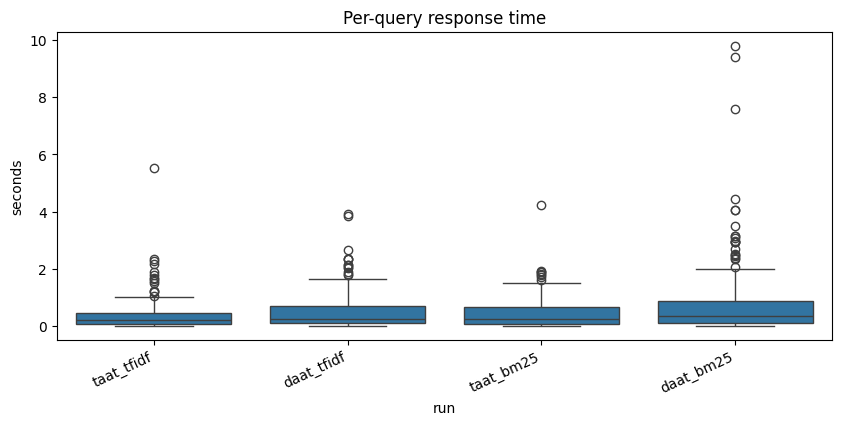

,count,mean,std,min,25%,50%,75%,max
run,,,,,,,,
daat_bm25,200.0,0.793479,1.349766,0.000156,0.082597,0.329732,0.860596,9.809756
daat_tfidf,200.0,0.510034,0.663449,0.000099,0.078567,0.236812,0.707526,3.899900
taat_bm25,200.0,0.446214,0.536714,0.000078,0.070167,0.226142,0.646074,4.242225
taat_tfidf,200.0,0.371204,0.564641,0.000135,0.062190,0.198287,0.452349,5.532269


In [66]:
timing_df = pd.DataFrame(
    [
        {"run": run_name, "seconds": value}
        for run_name, values in timings.items()
        for value in values
    ]
)

plt.figure(figsize=(10, 4))
sns.boxplot(data=timing_df, x="run", y="seconds")
plt.xticks(rotation=25, ha="right")
plt.title("Per-query response time")
plt.show()

timing_df.groupby("run")["seconds"].describe()


### Runtime Comparison Interpretation

The updated runtime plot compares per-query response time for the four retrieval configurations on the full-run setting. Overall, the BM25 methods show better runtime behavior than the TF-IDF methods.

`taat_bm25` is the most stable method: its box is the smallest, its median is low, and its outliers remain relatively limited. This means most BM25 TAAT queries are processed quickly and with little variation.

`daat_bm25` is also efficient, but it has a slightly wider spread and more high-latency outliers than `taat_bm25`. This suggests that DAAT with BM25 is usually fast, but certain queries still require scanning enough postings to increase response time.

The TF-IDF methods are slower and more variable. `daat_tfidf` has a wider interquartile range than `taat_tfidf`, meaning its typical query times vary more. It also has several outliers above 4 seconds and one around 6 seconds. `taat_tfidf` has the largest single outlier, close to 8 seconds, showing that some individual queries can be expensive when their terms have long posting lists.

In conclusion, the updated plot suggests that BM25 retrieval is generally faster and more stable than TF-IDF in this implementation. Among the four methods, `taat_bm25` appears to provide the best latency profile, while the TF-IDF configurations show higher variability and more extreme slow queries.

## Evaluation With Relevance Judgments

`ir_measures` can evaluate the run objects directly. We use common ranked retrieval metrics:

- `P@10`: precision in the first 10 results.
- `nDCG@10`: rewards relevant documents near the top of the ranking.
- `AP`: average precision across the ranked list.
- `RR`: reciprocal rank of the first relevant document.

If you built a partial index with `MAX_DOCS`, metrics may be artificially low because relevant documents outside the partial index cannot be retrieved.


## Evaluation
This evaluation section follows `IR/60. Evaluation.ipynb`, where `ir_measures` is used to calculate aggregate effectiveness metrics. 

In [67]:
# load the relevance judgements and define the metrics (these represent the ground truth used to evaluate the search engine)
qrels = list(queries_dataset.qrels_iter())

# define the metrics we want to use 
metrics = [P@10, nDCG@10, AP, RR]

evaluation_rows = []
for run_name, run in runs.items():
    # we loop through the 4 retrieval runs (taat_tfidf, daat_tfidf, taat_bm25, daat_bm25)
    # for each run 

    # compare our retrieved results agains the qrels 
    # calc_aggregate : compute the metric over all queries and return the avg result
    scores = ir_measures.calc_aggregate(metrics, qrels, run)

    # build one table row per run 
    row = {"run": run_name}
    row.update({str(metric): value for metric, value in scores.items()})
    evaluation_rows.append(row)

# create a dataframe and sort the systems by nDCG@10
evaluation_df = pd.DataFrame(evaluation_rows).sort_values("nDCG@10", ascending=False)
evaluation_df


,run,AP,P@10,nDCG@10,RR
3,daat_bm25,0.373521,0.7655,0.517139,0.947860
2,taat_bm25,0.373518,0.7655,0.517139,0.947860
1,daat_tfidf,0.159510,0.3805,0.313448,0.657519
0,taat_tfidf,0.159671,0.3805,0.313448,0.657519


## Evaluation With `trec_eval`

In addition to `ir_measures`, we also export qrels and runs in standard TREC format and evaluate them with the external `trec_eval` command-line tool (written in C). This makes the results easier to compare with traditional IR workflows.

* The qrels format is `qid 0 docno relevance`
* The run format is `qid Q0 docno rank score run_name`


`ir_measures` = Python-natie evaluation 
`trec_eval`   = classic command-line IR evaluation 

They evaluate the same runs, but `trec_eval` requires files in a specific format. 

In [69]:
!git clone https://github.com/usnistgov/trec_eval.git
!cd trec_eval && make

Clone in 'trec_eval' in corso...
remote: Enumerating objects: 1214, done.
remote: Counting objects: 100% (399/399), done.jects:  78% (312/399)
remote: Compressing objects: 100% (135/135), done.
remote: Total 1214 (delta 304), reused 325 (delta 258), pack-reused 815 (from 1)
Ricezione degli oggetti: 100% (1214/1214), 1.56 MiB | 869.00 KiB/s, fatto.
Risoluzione dei delta: 100% (809/809), fatto.
gcc -g -I.  -Wall -Wno-macro-redefined -DVERSIONID=\"10.0-rc2\"  -o trec_eval trec_eval.c formats.c meas_init.c meas_acc.c meas_avg.c meas_print_single.c meas_print_final.c gain_init.c get_qrels.c get_trec_results.c get_prefs.c get_qrels_prefs.c get_qrels_jg.c form_res_rels.c form_res_rels_jg.c form_prefs_counts.c utility_pool.c get_zscores.c convert_zscores.c measures.c  m_map.c m_P.c m_num_q.c m_num_ret.c m_num_rel.c m_num_rel_ret.c m_gm_map.c m_Rprec.c m_recip_rank.c m_bpref.c m_iprec_at_recall.c m_recall.c m_Rprec_mult.c m_utility.c m_11pt_avg.c m_ndcg.c m_ndcg_cut.c m_Rndcg.c m_ndcg_rel.c m_b

In [ ]:
import shutil
# subprocess is used to call trec_eval from inside pYTON
import subprocess



TREC_EVAL_DIR = Path("trec_eval_files")
TREC_QRELS_PATH = TREC_EVAL_DIR / "antique_test.qrels"


def save_trec_qrels(qrels, output_path):
    """
    This function saves the relevance judgements in TREC qrels format
    Each line is written like:
        query_id    0   doc_id    relevance
    
    (0 is a standard unused field in qrels)
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open("w") as file:
        for qrel in qrels:
            file.write(f"{qrel.query_id} 0 {qrel.doc_id} {int(qrel.relevance)}\n")


def save_trec_run(run, output_path, run_name):
    """
    This function saves our retrieved results in TREC run format 
    Each line is: 
        qid   Q0   docno   rank    score   run_name
    " for query {quid}, document {docno} is ranked {rank} with score {score} by run {run_name} "
    """
    grouped = defaultdict(list)
    for scored_doc in run:
        grouped[scored_doc.query_id].append(scored_doc)

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open("w") as file:
        for query_id, scored_docs in grouped.items():
            scored_docs = sorted(scored_docs, key=lambda item: item.score, reverse=True)
            for rank, scored_doc in enumerate(scored_docs, start=1):
                file.write(f"{query_id} Q0 {scored_doc.doc_id} {rank} {scored_doc.score:.6f} {run_name}\n")


def run_trec_eval(qrels_path, run_path, trec_eval_binary="trec_eval"):
    """
    This function actually calls trec_eval 
    """
    command = [
        trec_eval_binary,
        "-m", "P.10",               # P@10
        "-m", "ndcg_cut.10",        # nDCG@10
        "-m", "map",                # AP
        "-m", "recip_rank",         # RR
        str(qrels_path),
        str(run_path),
    ]

    # run the command: here we are calling the executable from Python
    completed = subprocess.run(command, capture_output=True, text=True, check=True)
    scores = {}
    for line in completed.stdout.splitlines():
        parts = line.split()
        if len(parts) == 3 and parts[1] == "all":
            scores[parts[0]] = float(parts[2])
    return scores

# check if trec_eval is installed and available from the terminal 
trec_eval_binary = shutil.which("trec_eval") or "./trec_eval/trec_eval"

if trec_eval_binary is None:
    trec_eval_df = pd.DataFrame()
    print("trec_eval was not found on PATH. Install the trec_eval command-line tool, then rerun this cell.")
else:
    # write the qrels file
    save_trec_qrels(qrels, TREC_QRELS_PATH)

    trec_eval_rows = []
    for run_name, run in runs.items():
        # loop through the baseline runs. For each run 
        run_path = TREC_EVAL_DIR / f"{run_name}.run"
        # 1. save the run file
        save_trec_run(run, run_path, run_name)
        row = {"run": run_name}
        # 2. call trec_eval
        row.update(run_trec_eval(TREC_QRELS_PATH, run_path, trec_eval_binary=trec_eval_binary))
        # 3. store the metric values
        trec_eval_rows.append(row)

    trec_eval_df = pd.DataFrame(trec_eval_rows)
    sort_column = "ndcg_cut_10" if "ndcg_cut_10" in trec_eval_df.columns else "map"
    trec_eval_df = trec_eval_df.sort_values(sort_column, ascending=False)
    display(trec_eval_df)


,run,map,recip_rank,P_10,ndcg_cut_10
3,daat_bm25,0.3773,0.9574,0.7732,0.5224
2,taat_bm25,0.3773,0.9574,0.7732,0.5224
1,daat_tfidf,0.1611,0.6642,0.3843,0.3166
0,taat_tfidf,0.1613,0.6642,0.3843,0.3166


## Differentiating Experiment: Query Term Coverage

The idea here is: if two documents have similar BM25 scores, the one matching more distinct query terms may better cover the user's information need.

### **The Converage Idea**
* A normal BM25 score asks how strongly does a document match the query terms
* The coverage variant adds another question: "how many different query terms does this document match?"

Basically if we have two documents where one covers more of the query's meaning because it matches more different query terms, than that one document should get a small bonus.
That is what we call **query term coverage**

In [ ]:
def taat_bm25_with_coverage(query_text, index, scorer="bm25", k=TOP_K, coverage_weight=1.0):
    """
    This function defines a retriever like taat_retrieve, but secialized for BM25+coverage
    - coverage_weight = 1.0 <-- how strong the coverage bonus should be 

    Final formula:
    final score = BM25 score + coverage_weight * coverage
    """
    terms, postings = prepare_query(query_text, index)

    # this stores each doc's BM25 score 
    accumulators = defaultdict(float)

    # this is the NEW part: it stores which query terms each doc matched
    # a set is used because we only care wether the doc matched a term, not how many times for coverage
    matched_terms = defaultdict(set)

    for term, posting in zip(terms, postings):
        # loop through every query term and its posting list 

        # move the posting iterator to the beginning 
        posting.reset()

        # get how many docs contain this term (for IDF)
        document_frequency = index.lexicon[term]["df"]

        while not posting.is_end_list():
            # scan every doc that contains the current term 

            internal_docid = posting.docid()
            doc = index.doc_index[internal_docid]

            # normal BM25 score
            score = bm25_score(posting.frequency(), document_frequency, doc["length"], index)

            # add that BM25 contribution to the doc's tot score
            accumulators[doc["docno"]] += score

            # coverage specific line: we record that docno matched term
            matched_terms[doc["docno"]].add(term)

            # move to next doc in posting list 
            posting.next()

    query_term_count = max(len(terms), 1)
    for docno, terms_seen in matched_terms.items():
        # loop over every doc that matched at least one query term

        # compute the fraction of query terms matched 
        coverage = len(terms_seen) / query_term_count

        # add the coverage bonus to the doc's BM25 score
        accumulators[docno] += coverage_weight * coverage

    top = TopQueue(k=k)
    for docno, score in accumulators.items():
        top.insert(docno, score)
    return top.sorted_results()


## Evaluate The Coverage Variant

This experiment can be repeated with different `coverage_weight` values. For a clean report, we run the full query set and compare the variant against plain BM25.


In [ ]:
coverage_run, coverage_timing = build_run(
    queries_dataset,
    index,
    retriever=taat_bm25_with_coverage,   # we use our custom BM25+coverage
    scorer="bm25",                       # just for compatibility
    k=TOP_K,
    max_queries=MAX_QUERIES,
)


coverage_scores = ir_measures.calc_aggregate(metrics, qrels, coverage_run)
coverage_scores


Running taat_bm25_with_coverage bm25: 100%|██████████| 200/200 [04:18<00:00,  1.29s/it]

build_run: 258359.15 ms


{AP: 0.3764053712371602,
 P@10: 0.7660000000000005,
 nDCG@10: 0.5178355881120964,
 RR: 0.9479322344322343}

We observe how the BM25 + coverage variant with `coverage_weight = 1.0` did not improve over the plain BM25 baseline. Its effectiveness is slightly lower across all metrics: `AP`, `P@10`, `nDCG@10`, and `RR`. This suggests that the explicit coverage bonus may be too strong or unnecessary in this setting, because standard BM25 already rewards documents that match multiple query terms through the sum of term contributions. 

Therefore, the coverage idea should be treated as an experimental heuristic rather than a better default ranking function.
We'll still try testing multiple coverage weights to see if something changes.

### Evaluation Summary Graphs

We compare retrieval methods both by runtime and by retrieval quality with graphs, which make it easier to see which method is best for each metric.

In the following cells we plot the main aggregate metrics for TF-IDF and BM25 with both TAAT and DAAT processing. TAAT and DAAT should normally return the same ranking for the same scorer


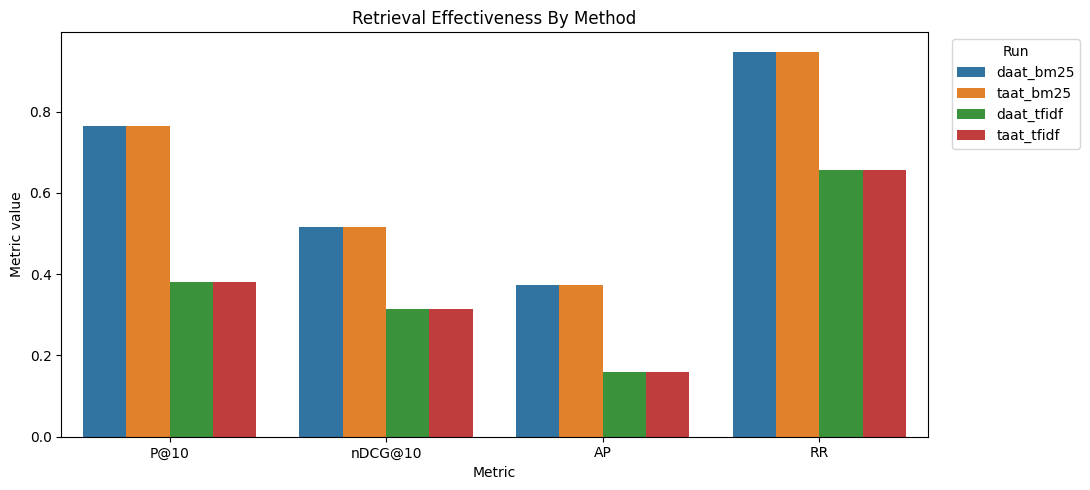

In [73]:
metric_columns = [column for column in ['P@10', 'nDCG@10', 'AP', 'RR'] if column in evaluation_df.columns]

if metric_columns:
    evaluation_long_df = evaluation_df.melt(id_vars='run', value_vars=metric_columns, var_name='metric', value_name='value')

    plt.figure(figsize=(11, 5))
    sns.barplot(data=evaluation_long_df, x='metric', y='value', hue='run')
    plt.title('Retrieval Effectiveness By Method')
    plt.ylabel('Metric value')
    plt.xlabel('Metric')
    plt.legend(title='Run', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('Run the evaluation cell first.')


### Retrieval Effectiveness Interpretation

The graph compares the effectiveness of the four baseline retrieval methods: TAAT and DAAT with TF-IDF, and TAAT and DAAT with BM25.

The clearest result is that BM25 strongly outperforms TF-IDF across all metrics. For `P@10`, BM25 retrieves relevant documents in the top 10 much more often than TF-IDF. The same pattern appears for `nDCG@10`, meaning BM25 is not only retrieving more relevant documents, but also ranking them better near the top.

BM25 also has a much higher `AP`, which shows that its advantage is not limited to the first 10 results: it provides better ranking quality across the retrieved list. The `RR` score is also higher for BM25, meaning the first relevant document usually appears very early in the ranking.

TAAT and DAAT produce almost identical effectiveness for the same scoring function. This is expected because TAAT and DAAT are different query-processing strategies, but they compute the same TF-IDF or BM25 document scores. Their main difference is runtime behavior, not ranking effectiveness.

Overall, the graph confirms that the scoring function has a much larger impact on retrieval quality than the traversal strategy. BM25 is the best baseline method in this experiment, while TF-IDF is consistently weaker.

### Per-Query Evaluation Diagnostics

This section extends `IR/60. Evaluation.ipynb`, which shows how to compute both aggregate and per-query metrics with `ir_measures`.

Aggregate scores can hide instability: one method may be best on average but fail badly on specific queries. Here we compute per-query `nDCG@10` and compare the two most important baselines, TAAT BM25 and TAAT TF-IDF.


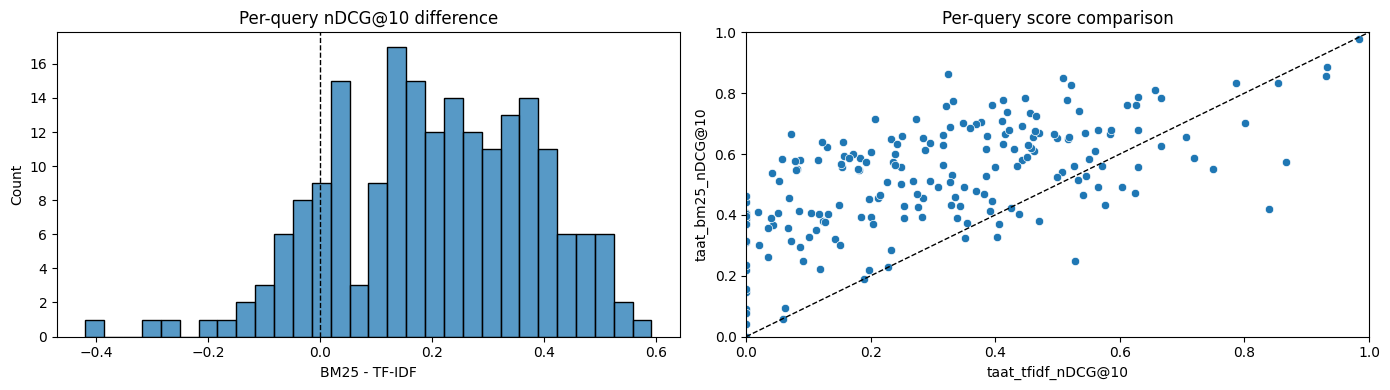

,query_id,taat_bm25_nDCG@10,taat_tfidf_nDCG@10,bm25_minus_tfidf
21,1373069,0.664291,0.071932,0.592359
73,2528767,0.864350,0.324584,0.539766
100,3074429,0.585241,0.057908,0.527332
158,4283542,0.640031,0.121762,0.518269
95,2864267,0.715450,0.206420,0.509029


,query_id,taat_bm25_nDCG@10,taat_tfidf_nDCG@10,bm25_minus_tfidf
138,3910925,0.420240,0.839480,-0.419240
1,1015624,0.572714,0.866257,-0.293543
191,821387,0.248908,0.528584,-0.279675
84,2783398,0.552145,0.749901,-0.197756
74,2529114,0.473496,0.623921,-0.150425


In [ ]:
def per_query_metric(run, qrels, metric):
    """
    This helper computes one metric separately for each query
    The function returns a dictionary, where each value is the metric score for that query
    """
    return {
        measurement.query_id: measurement.value

        # here we use iter_calc, that gives one measurement at a time, per query
        for measurement in ir_measures.iter_calc([metric], qrels, run)
    }

if 'taat_bm25' in runs and 'taat_tfidf' in runs:
    bm25_query_scores = per_query_metric(runs['taat_bm25'], qrels, nDCG@10)
    tfidf_query_scores = per_query_metric(runs['taat_tfidf'], qrels, nDCG@10)

    # we get all query ids that appear in either dictionary
    compared_qids = sorted(set(bm25_query_scores) | set(tfidf_query_scores))

    # dataframe with one row per query
    # if a query is missing for one method --> .get(qid, 0.0) fills the score with 0.0
    per_query_df = pd.DataFrame({
        'query_id': compared_qids,
        'taat_bm25_nDCG@10': [bm25_query_scores.get(qid, 0.0) for qid in compared_qids],
        'taat_tfidf_nDCG@10': [tfidf_query_scores.get(qid, 0.0) for qid in compared_qids],
    })

    # difference for each query
    per_query_df['bm25_minus_tfidf'] = per_query_df['taat_bm25_nDCG@10'] - per_query_df['taat_tfidf_nDCG@10']
    # if bm25_minus_tfidf > 0 --> BM25 did better on that query
    # otherwise               --> TF-IDF did better 

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(per_query_df['bm25_minus_tfidf'], bins=30, ax=axes[0])
    axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_title('Per-query nDCG@10 difference')
    axes[0].set_xlabel('BM25 - TF-IDF')

    sns.scatterplot(data=per_query_df, x='taat_tfidf_nDCG@10', y='taat_bm25_nDCG@10', ax=axes[1])
    axes[1].plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1)
    axes[1].set_title('Per-query score comparison')
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

    # the 5 queries where BM25 beats TF-IDF the most 
    display(per_query_df.sort_values('bm25_minus_tfidf', ascending=False).head(5))

    # the 5 queries where TF-IDF beats BM25 the most 
    display(per_query_df.sort_values('bm25_minus_tfidf').head(5))
else:
    print('Build the baseline runs first.')


# The first histogram shows the distribution of differences. The vertical line at 0 separates:
# * left side  : TF-IDF better 
# * right side : BM25 better 

# The second plot compaes the two systems query by query. Each point is one query 
# - the x-axis is TF-IDF score 
# - the y-axis is BM25 score
# The diagonal line means equal performance 
# * if a point is above the line --> BM25 is better 
# * if a point is below the line --> TF-IDF is better 

### Coverage Weight Tuning
The first coverage cell used a single default weight; this section turns the idea into a real tuning experiment.

We test several coverage weights and evaluate each run with the same metrics as the baselines. The goal is not only to find the best weight, but also to see whether the variant improves consistently or only by chance on one setting.


In [75]:
def make_coverage_retriever(coverage_weight):
    def coverage_retriever(query_text, index, scorer='bm25', k=TOP_K):
        return taat_bm25_with_coverage(
            query_text,
            index,
            scorer=scorer,
            k=k,
            coverage_weight=coverage_weight,
        )
    coverage_retriever.__name__ = f'taat_bm25_coverage_{coverage_weight}'
    return coverage_retriever

coverage_weights = [0.0, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0]
coverage_rows = []
coverage_runs = {}
coverage_timings = {}

for weight in coverage_weights:
    run_name = f'coverage_{weight:g}'
    coverage_runs[run_name], coverage_timings[run_name] = build_run(
        queries_dataset,
        index,
        retriever=make_coverage_retriever(weight),
        scorer='bm25',
        k=TOP_K,
        max_queries=MAX_QUERIES,
    )
    scores = ir_measures.calc_aggregate(metrics, qrels, coverage_runs[run_name])
    row = {'coverage_weight': weight, 'run': run_name, 'mean_query_time_s': float(np.mean(coverage_timings[run_name]))}
    row.update({str(metric): value for metric, value in scores.items()})
    coverage_rows.append(row)

coverage_tuning_df = pd.DataFrame(coverage_rows).sort_values('nDCG@10', ascending=False)
coverage_tuning_df


Running taat_bm25_coverage_0.0 bm25: 100%|██████████| 200/200 [03:06<00:00,  1.07it/s]


build_run: 186685.30 ms


Running taat_bm25_coverage_0.25 bm25: 100%|██████████| 200/200 [04:35<00:00,  1.38s/it]


build_run: 275548.54 ms


Running taat_bm25_coverage_0.5 bm25: 100%|██████████| 200/200 [07:12<00:00,  2.16s/it]


...

Running taat_bm25_coverage_3.0 bm25: 100%|██████████| 200/200 [02:36<00:00,  1.27it/s]


build_run: 156899.03 ms


Running taat_bm25_coverage_5.0 bm25: 100%|██████████| 200/200 [03:48<00:00,  1.14s/it]


build_run: 228457.69 ms


,coverage_weight,run,mean_query_time_s,AP,P@10,nDCG@10,RR
6,5.00,coverage_5,1.131863,0.380131,0.7620,0.520315,0.947794
5,3.00,coverage_3,0.778174,0.379234,0.7640,0.517876,0.946179
3,1.00,coverage_1,1.522694,0.376405,0.7660,0.517836,0.947932
2,0.50,coverage_0.5,2.145761,0.374907,0.7670,0.517736,0.947881
4,2.00,coverage_2,0.863386,0.377161,0.7645,0.517425,0.945464
1,0.25,coverage_0.25,1.369276,0.373955,0.7665,0.517248,0.947881
0,0.00,coverage_0,0.924807,0.373518,0.7655,0.517139,0.947860


The coverage-weight tuning experiment shows that adding an explicit query-term coverage bonus can slightly improve retrieval effectiveness, but the effect is limited. The best setting according to `nDCG@10` is `coverage_weight = 5.0`, which improves `nDCG@10` from `0.517139` without coverage to `0.520315`. It also improves `AP` from `0.373518` to `0.380131`, suggesting that rewarding documents matching more distinct query terms can improve the overall ranking.

However, the improvement is not consistent across all metrics. `P@10` does not improve at the best coverage weight; the highest `P@10` is obtained with `coverage_weight = 0.5`. `RR` remains almost unchanged across all settings, meaning that the coverage bonus has little impact on the rank of the first relevant document.

Overall, the coverage variant is useful as an experimental ranking heuristic, but the gains are small. The results suggest that standard BM25 already captures much of the benefit of matching multiple query terms, while an additional coverage bonus can provide a modest improvement when carefully tuned.

### Coverage Tuning Graphs

This cell visualizes the coverage experiment. If the curve improves and then decreases, it means a small coverage reward helps, but too much coverage reward overwhelms the BM25 score.


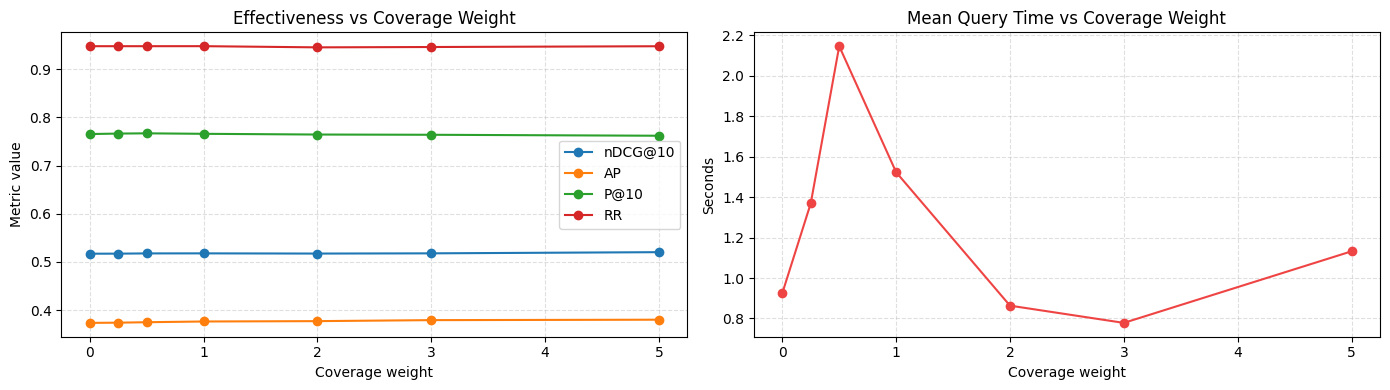

In [76]:
if 'coverage_tuning_df' in globals() and len(coverage_tuning_df) > 0:
    plot_df = coverage_tuning_df.sort_values('coverage_weight')
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for metric_name in [column for column in ['nDCG@10', 'AP', 'P@10', 'RR'] if column in plot_df.columns]:
        axes[0].plot(plot_df['coverage_weight'], plot_df[metric_name], marker='o', label=metric_name)
    axes[0].set_title('Effectiveness vs Coverage Weight')
    axes[0].set_xlabel('Coverage weight')
    axes[0].set_ylabel('Metric value')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.4)

    axes[1].plot(plot_df['coverage_weight'], plot_df['mean_query_time_s'], marker='o', color='#ef4444')
    axes[1].set_title('Mean Query Time vs Coverage Weight')
    axes[1].set_xlabel('Coverage weight')
    axes[1].set_ylabel('Seconds')
    axes[1].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()
else:
    print('Run coverage tuning first.')


### What happens if we change the strength of the coverage bonus?
- Tested weights are: `[0.0, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0]`
## Left Plot: Effectiveness vs Coverage Weight 
Here we show retrieval quality 
* x-axis : coverage_weight 
* y_axis : metric value 
* each colored line is one metric 

The lines are almost flat. This means changing the coverage weight does not dramatically change retrieval effectiveness. 
Still, there are small differences 
- `nDCG@10` slightly improves at higher weights --> the best `nDCG@10` is at weight `5.0`. This suggests that a stronger coverage bonus could slightly improve ordering of docs near the top 
- `AP` also improves with larger coverage weights 
- `P@10` is very stable and does not clearly improve, so coverage is not strongly changing the number of relevant docs in the top 10 
- `RR` is almost flat, which means that the first rel doc is already appearing very early with pain BM25, and coverage does not change that much

As a conclusion we can say that coverage can slightly improve AP and nDCG@10, but the overall impact is modest.

## Right Plot: Mean Query Time vs Coverage Weight
In theory, coverage weight should not drastically change runtime, because the algorithm scans the same posting lists regardless of the weight.
For every weight the function still does:
1. prepare query
2. scan postings
3. compute BM25
4. track matched terms
5. add coverage bonus
6. select top-k

So runtime difference here are probably due to execution noise. The spike is likely outlier/noise effect. 
Runtime does not show a meaningful relationship with coverage weight.

### BM25 Parameter Tuning

This section extends the BM25 scoring implementation from `IR/50. Query Processing.ipynb`.

BM25 has two important parameters: `k1`, which controls term-frequency saturation, and `b`, which controls document-length normalization. The baseline uses the common values `k1=1.2` and `b=0.75`; here we test a compact grid to see whether Antique prefers a different setting.


In [ ]:
def taat_bm25_param_retrieve(query_text, index, scorer='bm25', k=TOP_K, k1=1.2, b=0.75):
    """
    BM25 has 2 params: 
    - k1 
    - b 
    the default values we used up until now are (k1=1.2, b=0.75)
    Here we want to test whether another cobination works better for Antique. 
    This function is a TAAT BM25 retriever where we can choose k1 and b. 
    """

    # prepare query terms and posting lists
    terms, postings = prepare_query(query_text, index)

    # score accumulator for cos 
    accumulators = defaultdict(float)

    for term, posting in zip(terms, postings):
        posting.reset()
        document_frequency = index.lexicon[term]['df']

        while not posting.is_end_list():
            # scan every doc containing that term
            internal_docid = posting.docid()
            doc = index.doc_index[internal_docid]

            # key line : this calls the same BM25 formula but passes custom values for k1, b
            score = bm25_score(posting.frequency(), document_frequency, doc['length'], index, k1=k1, b=b)
            accumulators[doc['docno']] += score
            posting.next()

    top = TopQueue(k=k)
    for docno, score in accumulators.items():
        top.insert(docno, score)
    return top.sorted_results()


def make_bm25_param_retriever(k1, b):
    """
    Create a retriever function with fixed k1, b
    """
    def bm25_param_retriever(query_text, index, scorer='bm25', k=TOP_K):
        """
        This wrapper is needed because build_run() expects retrievers to have this shape:
        retriever(query_text, index, scorer=scorer, k=k)

        but we also want to inject k1 and b, so make_bm25_param_retriever(k1,b) creates a retriever that always uses (k1=k1,b=b)
        """
        return taat_bm25_param_retrieve(query_text, index, scorer=scorer, k=k, k1=k1, b=b)
    bm25_param_retriever.__name__ = f'taat_bm25_k1_{k1}_b_{b}'
    return bm25_param_retriever

# grid of param combinations we test 
bm25_param_grid = [
    {'k1': 0.8, 'b': 0.3},
    {'k1': 0.8, 'b': 0.75},
    {'k1': 1.2, 'b': 0.3},
    {'k1': 1.2, 'b': 0.75},
    {'k1': 1.6, 'b': 0.75},
    {'k1': 2.0, 'b': 0.75},
]

bm25_tuning_rows = []
bm25_tuning_runs = {}

for params in bm25_param_grid:
    run_name = f"bm25_k1_{params['k1']}_b_{params['b']}"
    run, run_timing = build_run(
        queries_dataset,
        index,
        retriever=make_bm25_param_retriever(params['k1'], params['b']),
        scorer='bm25',
        k=TOP_K,
        max_queries=MAX_QUERIES,
    )
    bm25_tuning_runs[run_name] = run
    scores = ir_measures.calc_aggregate(metrics, qrels, run)
    row = {'run': run_name, 'k1': params['k1'], 'b': params['b'], 'mean_query_time_s': float(np.mean(run_timing))}
    row.update({str(metric): value for metric, value in scores.items()})
    bm25_tuning_rows.append(row)

bm25_tuning_df = pd.DataFrame(bm25_tuning_rows).sort_values('nDCG@10', ascending=False)
bm25_tuning_df


Running taat_bm25_k1_0.8_b_0.3 bm25: 100%|██████████| 200/200 [03:12<00:00,  1.04it/s]


build_run: 192739.63 ms


Running taat_bm25_k1_0.8_b_0.75 bm25: 100%|██████████| 200/200 [04:18<00:00,  1.29s/it]


build_run: 258453.90 ms


Running taat_bm25_k1_1.2_b_0.3 bm25: 100%|██████████| 200/200 [01:54<00:00,  1.74it/s]


...

Running taat_bm25_k1_1.6_b_0.75 bm25: 100%|██████████| 200/200 [01:10<00:00,  2.83it/s]


build_run: 70586.80 ms


Running taat_bm25_k1_2.0_b_0.75 bm25: 100%|██████████| 200/200 [01:07<00:00,  2.97it/s]

build_run: 67374.84 ms


,run,k1,b,mean_query_time_s,AP,P@10,nDCG@10,RR
0,bm25_k1_0.8_b_0.3,0.8,0.30,0.945584,0.364467,0.7130,0.533834,0.923572
2,bm25_k1_1.2_b_0.3,1.2,0.30,0.568009,0.364972,0.7120,0.532975,0.921833
1,bm25_k1_0.8_b_0.75,0.8,0.75,1.269673,0.391245,0.7750,0.528276,0.945353
3,bm25_k1_1.2_b_0.75,1.2,0.75,0.585244,0.373518,0.7655,0.517139,0.947860
4,bm25_k1_1.6_b_0.75,1.6,0.75,0.348771,0.356857,0.7500,0.506271,0.951944
5,bm25_k1_2.0_b_0.75,2.0,0.75,0.331872,0.341136,0.7360,0.495924,0.952639


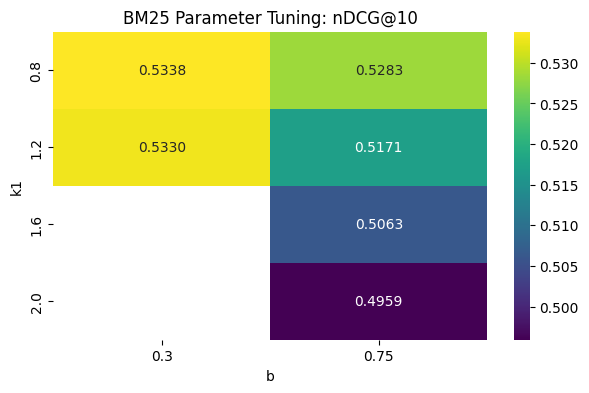

In [78]:
if 'bm25_tuning_df' in globals() and len(bm25_tuning_df) > 0:
    heatmap_df = bm25_tuning_df.pivot(index='k1', columns='b', values='nDCG@10')
    plt.figure(figsize=(7, 4))
    sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='viridis')
    plt.title('BM25 Parameter Tuning: nDCG@10')
    plt.ylabel('k1')
    plt.xlabel('b')
    plt.show()
else:
    print('Run BM25 parameter tuning first.')


The BM25 parameter tuning heatmap shows that the best tested configuration is `k1 = 0.8` and `b = 0.3`, with `nDCG@10 = 0.5338`. This improves over the default BM25 setting (`k1 = 1.2`, `b = 0.75`), which obtains `nDCG@10 = 0.5171`.

The results suggest that Antique benefits from weaker document-length normalization. The lower value `b = 0.3` consistently performs better than `b = 0.75`, indicating that long documents should not be penalized too strongly. The results also suggest that lower term-frequency saturation works better: increasing `k1`, especially with `b = 0.75`, reduces effectiveness. Overall, tuning BM25 parameters improves retrieval quality compared with the standard default values.

### Repeated Query Cache Experiment

Here we focus on the most practical cache for a search application: repeated query-result caching.

The first pass computes BM25 results normally and stores them. The second pass asks the same queries again and should be faster because results are returned from the cache.


Running cached_taat_retrieve bm25:   0%|          | 0/100 [00:00<?, ?it/s]

Running cached_taat_retrieve bm25: 100%|██████████| 100/100 [00:32<00:00,  3.12it/s]


build_run: 32017.98 ms


Running cached_taat_retrieve bm25: 100%|██████████| 100/100 [00:00<00:00, 845.77it/s]


build_run: 223.58 ms


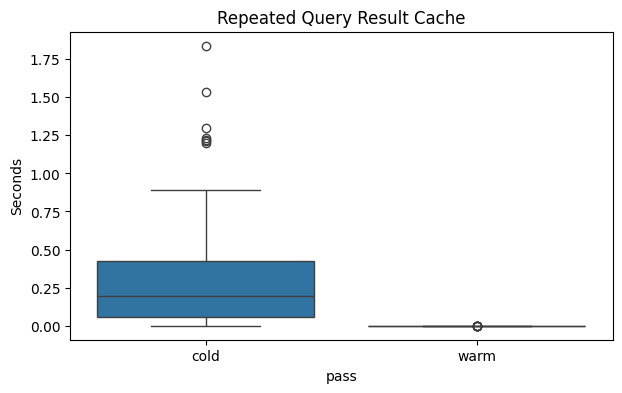

,count,mean,std,min,25%,50%,75%,max
pass,,,,,,,,
cold,100.0,0.316368,0.365762,1.576210e-04,0.057845,0.193816,0.424413,1.838464
warm,100.0,0.000004,0.000004,8.350034e-07,0.000002,0.000002,0.000004,0.000029


In [ ]:
def cached_retriever_factory(base_retriever):
    """
    Function that creates a cached version of another retriever
    - base_retriever could be taat_retrieve 
    - the local disctionary cache stores previously computed query results 
    """
    cache = {}

    def cached_retriever(query_text, index, scorer='bm25', k=TOP_K):
        """
        This is the new retriever function that wraps the original retriever 
        It accepts the same kind of arguments as the other retrievers 
        """

        # this creates a cache key 
        # the key is a tuple containing (query text, scoring function, number of requested results)
        # we include all three because changin one could produce different results --> they should have different cache entries
        key = (query_text, scorer, k)
        if key not in cache:
            # not seen yet 
            # cache miss -> compute retrieval -> store result
            cache[key] = base_retriever(query_text, index, scorer=scorer, k=k)

        # from 2nd time on :
        # cache hit -> return stores result immediately 
        return cache[key]

    # give the cached function a readable name and attach the cache dictionary to it, so we can inspect it if needed 
    cached_retriever.__name__ = f'cached_{base_retriever.__name__}'
    cached_retriever.cache = cache
    return cached_retriever

# limit the cache experiment to at most 100 queries 
cache_query_limit = min(MAX_QUERIES or 100, 100)

# this creates a cached version of taat_retrieve
cached_bm25 = cached_retriever_factory(taat_retrieve)

# FIRST PASS: The COLD PASS 
# "cold" because cache is empty
# for each query: not in cache -> compute BM25 -> store results
_, cache_cold_times = build_run(
    queries_dataset,
    index,
    retriever=cached_bm25,
    scorer='bm25',
    k=TOP_K,
    max_queries=cache_query_limit,
)

# SECOND PASS: The WARM PASS 
# this runs the exact same queries again with the same cached retriever 
# cache already contains results from the first pass
# for each query: in cache -> return result directly 
_, cache_warm_times = build_run(
    queries_dataset,
    index,
    retriever=cached_bm25,
    scorer='bm25',
    k=TOP_K,
    max_queries=cache_query_limit,
)

# datafame with two groupts: cold, warm and their per-query runtimes 
cache_experiment_df = pd.DataFrame({
    'pass': ['cold'] * len(cache_cold_times) + ['warm'] * len(cache_warm_times),
    'seconds': np.concatenate([cache_cold_times, cache_warm_times]),
})

plt.figure(figsize=(7, 4))
sns.boxplot(data=cache_experiment_df, x='pass', y='seconds')
plt.title('Repeated Query Result Cache')
plt.ylabel('Seconds')
plt.show()

cache_experiment_df.groupby('pass')['seconds'].describe()


The repeated-query cache experiment shows a very large latency reduction between the cold and warm passes. In the cold pass, the cache is empty, so each query must be processed normally; the mean response time is about `0.316s`. In the warm pass, the same queries are submitted again and their results are already stored in the cache, so the mean response time drops to about `0.000004s`.

This demonstrates that exact repeated-query caching can be extremely effective for reducing response time. The cache avoids scanning posting lists and recomputing BM25 scores when the same query, scorer, and top-k value are requested again. However, this optimization only applies to exact repeated queries; semantically similar but textually different queries would not reuse the same cache entry. The cache would also need to be cleared or updated if the index changed.

### Qualitative Error Analysis

Metrics tell us how much the system works; error analysis helps explain why it fails.

This section picks a query where TAAT BM25 performs poorly, prints the retrieved documents, and compares them with relevant documents from the qrels. On a partial index, some relevant documents may be outside the indexed subset; that is also a useful limitation to report.

In [82]:
def build_qrels_by_query(qrels):
    grouped = defaultdict(dict)
    for qrel in qrels:
        grouped[qrel.query_id][str(qrel.doc_id)] = int(qrel.relevance)
    return grouped


def run_to_ranked_docnos(run):
    grouped = defaultdict(list)
    for scored_doc in run:
        grouped[scored_doc.query_id].append((scored_doc.score, str(scored_doc.doc_id)))
    return {
        query_id: [doc_id for score, doc_id in sorted(items, reverse=True)]
        for query_id, items in grouped.items()
    }


def get_query_text_map(dataset, max_queries=None):
    return {query.query_id: query.text for query in iter_limited_queries(dataset, max_queries=max_queries)}

qrels_by_query = build_qrels_by_query(qrels)
bm25_ranked_docnos = run_to_ranked_docnos(runs['taat_bm25']) if 'taat_bm25' in runs else {}
query_text_map = get_query_text_map(queries_dataset, max_queries=MAX_QUERIES)
docno_to_internal = {doc['docno']: internal_id for internal_id, doc in index.doc_index.items()}

candidate_errors = []
for qid, ranked_docnos in bm25_ranked_docnos.items():
    relevant_docnos = {docno for docno, rel in qrels_by_query.get(qid, {}).items() if rel > 0}
    retrieved_top10 = ranked_docnos[:10]
    relevant_retrieved_top10 = len(set(retrieved_top10) & relevant_docnos)
    if relevant_docnos:
        candidate_errors.append({
            'query_id': qid,
            'query': query_text_map.get(qid, ''),
            'relevant_in_top10': relevant_retrieved_top10,
            'num_relevant_qrels': len(relevant_docnos),
            'retrieved_top10': retrieved_top10,
            'missed_relevant_indexed': [docno for docno in relevant_docnos if docno in docno_to_internal and docno not in retrieved_top10][:5],
        })

if candidate_errors:
    error_analysis_df = pd.DataFrame(candidate_errors).sort_values(
        ['relevant_in_top10', 'num_relevant_qrels'],
        ascending=[True, False],
    )
    selected_error = error_analysis_df.iloc[0]
else:
    error_analysis_df = pd.DataFrame()
    selected_error = None

if selected_error is not None:
    print('Selected query:', selected_error['query_id'])
    print('Query text:', selected_error['query'])
    print('Relevant docs in top 10:', selected_error['relevant_in_top10'], '/', selected_error['num_relevant_qrels'])

    print('\nTop retrieved documents:')
    show_results(selected_error['query'], taat_retrieve(selected_error['query'], index, scorer='bm25', k=10), index, max_rows=10)

    missed_rows = []
    for docno in selected_error['missed_relevant_indexed']:
        internal_id = docno_to_internal[docno]
        missed_rows.append({
            'docno': docno,
            'relevance': qrels_by_query[selected_error['query_id']].get(docno),
            'snippet': index.doc_index[internal_id]['text'][:350].replace('\n', ' '),
        })

    if missed_rows:
        print('\nRelevant indexed documents missed from the top 10:')
        display(pd.DataFrame(missed_rows))
    else:
        print('\nNo missed relevant documents from qrels are present in the partial index, or all indexed relevant documents were retrieved in the top 10.')
else:
    print('No suitable error-analysis query was found. Run more queries or use a larger index.')


Selected query: 2785579
Query text: If you could be an element of weather, which would you choose, and why?
Relevant docs in top 10: 0 / 39

Top retrieved documents:
Query: If you could be an element of weather, which would you choose, and why?
 1. 1578718_15 | 17.9886 | if i had to chose one super power it would be to control the elements.. if i had to choose one element it would be water, because it can exist in three states.
 2. 210036_4 | 13.2566 | Can you survive the hot weather without studying? Do you have a grasp on coping skills, or are you stranded on a desert island with only books and no refuge from the elements?
 3. 1578718_3 | 13.0200 | I think I would choose to grant wishes, because if I wanted to I could just wish for any sort of super power
 4. 2231084_1 | 12.8093 | It isn't a contradiction in terms.. . A democracy can manifest itself in many ways. If the people choose to have strict limitations on their individual liberties they can do that (theoretically you could ha

,docno,relevance,snippet
0,1706786_4,1,Why ask such a stupid question ?. If you...
1,4354146_3,2,depends on where the element is located
2,2785579_4,2,i would be rain so i can look down a girl's sh...
3,2785579_0,4,AIR !. Air is most vital for all human beings ...
4,389744_8,1,Why should we be able to have knive's or anyth...


### Qualitative Error Analysis

For the query `2785579` — *“If you could be an element of weather, which would you choose, and why?”* — the BM25 system retrieves no relevant documents in the top 10, even though there are 39 relevant documents according to the qrels.

Here we selected a query where BM25 fails badly. The query is asking for a personal hypothetical answer, like “air” or “rain”, but BM25 instead retrieves documents that contain words like “choose”, “element”, or “weather”, but in unrelated contexts. So the issue is not that the documents have no word overlap; the issue is that BM25 cannot understand the intent behind the query. Some relevant documents are actually indexed, but they are short and do not get enough score. This is a good example of the limitation of lexical retrieval.

## PyTerrier Baseline

Pyterrier is useful as an external baseline: compare our Python index against Terrier's built-in TF-IDF and BM25 implementations.
In the cell below we index Antique documents with PyTerrier, retrieve with Terrier BM25, and evaluate with AP, RR, nDCG@10, and P@10


In [ ]:
import pyterrier as pt

# Start PyTerrier if needed.
if not pt.started():
    pt.init()

print("Preparing Antique data for PyTerrier")

# Use the same datasets already loaded in the notebook.
docs_pt = pd.DataFrame(docs_dataset.docs_iter()).rename(
    columns={"doc_id": "docno", "text": "text"}
)
queries_pt = pd.DataFrame(queries_dataset.queries_iter()).rename(
    columns={"query_id": "qid", "text": "query"}
)
qrels_pt = pd.DataFrame(queries_dataset.qrels_iter()).rename(
    columns={"query_id": "qid", "doc_id": "docno", "relevance": "label"}
)

# PyTerrier expects ids as strings
docs_pt["docno"] = docs_pt["docno"].astype(str)
queries_pt["qid"] = queries_pt["qid"].astype(str)
qrels_pt["qid"] = qrels_pt["qid"].astype(str)
qrels_pt["docno"] = qrels_pt["docno"].astype(str)

# Optional: clean problematic query punctuation
def clean_query(query):
    return re.sub(r"[^\w\s]", "", query).strip()

queries_pt["query"] = queries_pt["query"].apply(clean_query)

# Respect the notebook runtime switches
if MAX_DOCS is not None:
    docs_pt = docs_pt.head(MAX_DOCS)

if MAX_QUERIES is not None:
    queries_pt = queries_pt.head(MAX_QUERIES)
    qrels_pt = qrels_pt[qrels_pt["qid"].isin(set(queries_pt["qid"]))]

print("Building PyTerrier index...")
indexer = pt.IterDictIndexer("./antique_pyterrier_index", overwrite=True)
index_ref = indexer.index(docs_pt.to_dict(orient="records"))

print("Retrieving with PyTerrier BM25")
pt_bm25 = pt.terrier.Retriever(index_ref, wmodel="BM25")
pt_bm25_results = pt_bm25.transform(queries_pt)

print("Evaluating PyTerrier BM25")
pt_bm25_scores = pt.Evaluate(
    pt_bm25_results,
    qrels_pt,
    metrics=[AP, RR, nDCG@10, P@10],
)

pt_bm25_scores

/var/folders/97/jl8q2szx5pj58rl9dj49cwzc0000gn/T/ipykernel_39305/2149617104.py:4: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /Users/martina/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependencies.jar: 100%|██████████| 99.6M/99.6M [01:00<00:00, 1.72MB/s]


Done
terrier-python-helper 0.0.8 jar not found, downloading to /Users/martina/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar: 100%|██████████| 36.6k/36.6k [00:00<00:00, 4.66MB/s]


Done


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/var/folders/97/jl8q2szx5pj58rl9dj49cwzc0000gn/T/ipykernel_39305/2149617104.py:5: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


Preparing Antique data for PyTerrier...
Building PyTerrier index...
23:15:35.583 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (730691_1) - further warnings are suppressed
23:20:46.833 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 2224 empty documents
Retrieving with PyTerrier BM25...
Evaluating PyTerrier BM25...


{'AP': 0.43877533165210436,
 'RR': 0.9119058475591495,
 'nDCG@10': 0.4991723645810082,
 'P@10': 0.7340000000000008}

These are the PyTerrier BM25 baseline results:
* AP       = 0.4388
* RR       = 0.9119
* nDCG@10  = 0.4992
* P@10     = 0.7340

Compared with our custom BM25 baseline from trec_eval:
* AP / MAP      = 0.3773
* RR            = 0.9574
* nDCG@10       = 0.5224
* P@10          = 0.7732

The PyTerrier BM25 baseline provides an external comparison against a mature IR toolkit. Its results are mixed compared with our custom BM25 implementation. PyTerrier obtains a higher `AP` (`0.4388`), suggesting better ranking quality across the broader retrieved list. However, our custom BM25 obtains higher top-rank metrics: `P@10`, `nDCG@10`, and `RR`.

This indicates that our implementation is competitive at the very top of the ranking, where search quality is most visible to users, while PyTerrier may retrieve relevant documents more consistently deeper in the ranked list. The difference may also be influenced by preprocessing, tokenization, stemming, stopword handling, and Terrier's internal indexing/scoring choices. 

### Final Best-System Selection

After running the baseline methods, the coverage-weight tuning, and the BM25 parameter tuning, we need to establish which run should be considered the project's best search system.

This cell gathers all available experiment tables, selects the run with the highest `nDCG@10`, and saves the corresponding run file. `nDCG@10` is used as the main selection metric because Antique relevance judgments are graded and the top of the ranking matters most in a search engine.


In [84]:
def save_trec_run(run, output_path, run_name):
    grouped = defaultdict(list)
    for scored_doc in run:
        grouped[scored_doc.query_id].append(scored_doc)

    output_path = Path(output_path)
    with output_path.open("w") as file:
        for query_id, scored_docs in grouped.items():
            scored_docs = sorted(scored_docs, key=lambda item: item.score, reverse=True)
            for rank, scored_doc in enumerate(scored_docs, start=1):
                file.write(f"{query_id} Q0 {scored_doc.doc_id} {rank} {scored_doc.score:.6f} {run_name}\n")

save_trec_run(runs["taat_bm25"], "taat_bm25.run", "taat_bm25")


In [ ]:
# to store metric rows for each candidate system 
candidate_run_rows = []

# to store actual run objects, so once we know the best run name, we can save its results
candidate_run_objects = {}

if 'evaluation_df' in globals():
    # only if evaluation_df exists 
    # it contains the baseline runs evaluation
    for _, row in evaluation_df.iterrows():
        run_name = row['run']
        if run_name in runs:
            candidate_row = row.to_dict()
            # each row gets this so later we know what that run came from
            candidate_row['source'] = 'baseline'
            candidate_run_rows.append(candidate_row)
            # save the actual retrieved results for that run 
            candidate_run_objects[run_name] = runs[run_name]

if 'coverage_tuning_df' in globals():
    # this adds the coverage-tuning runs 
    for _, row in coverage_tuning_df.iterrows():
        run_name = row['run']
        if 'coverage_runs' in globals() and run_name in coverage_runs:
            candidate_row = row.to_dict()
            candidate_row['source'] = 'coverage_tuning'
            candidate_run_rows.append(candidate_row)
            candidate_run_objects[run_name] = coverage_runs[run_name]

if 'bm25_tuning_df' in globals():
    # this adds BM25 parameter tuning runs 
    for _, row in bm25_tuning_df.iterrows():
        run_name = row['run']
        if 'bm25_tuning_runs' in globals() and run_name in bm25_tuning_runs:
            candidate_row = row.to_dict()
            candidate_row['source'] = 'bm25_parameter_tuning'
            candidate_run_rows.append(candidate_row)
            candidate_run_objects[run_name] = bm25_tuning_runs[run_name]

if candidate_run_rows:
    # if we collected at least one candidate 

    # create one big dataframe containing all candidate systems 
    final_system_selection_df = pd.DataFrame(candidate_run_rows)
    # sort by nDCG@10, highest first
    final_system_selection_df = final_system_selection_df.sort_values('nDCG@10', ascending=False).reset_index(drop=True)
    best_system = final_system_selection_df.iloc[0]
    best_run_name = best_system['run']
    best_run = candidate_run_objects[best_run_name]

    FINAL_RUN_PATH = Path('final_best_ir_run.run')
    save_trec_run(best_run, FINAL_RUN_PATH, best_run_name)

    print('Best run:', best_run_name)
    print('Source:', best_system.get('source'))
    print(f"Best nDCG@10: {best_system['nDCG@10']:.4f}")
    print('Saved final run file:', FINAL_RUN_PATH)
    display(final_system_selection_df.head(10))
else:
    print('Run the baseline evaluation and tuning sections before selecting the final system.')


Best run: bm25_k1_0.8_b_0.3
Source: bm25_parameter_tuning
Best nDCG@10: 0.5338
Saved final run file: final_best_ir_run.run


,run,AP,P@10,nDCG@10,RR,source,coverage_weight,mean_query_time_s,k1,b
0,bm25_k1_0.8_b_0.3,0.364467,0.7130,0.533834,0.923572,bm25_parameter_tuning,NaN,0.945584,0.8,0.30
1,bm25_k1_1.2_b_0.3,0.364972,0.7120,0.532975,0.921833,bm25_parameter_tuning,NaN,0.568009,1.2,0.30
2,bm25_k1_0.8_b_0.75,0.391245,0.7750,0.528276,0.945353,bm25_parameter_tuning,NaN,1.269673,0.8,0.75
3,coverage_5,0.380131,0.7620,0.520315,0.947794,coverage_tuning,5.00,1.131863,NaN,NaN
4,coverage_3,0.379234,0.7640,0.517876,0.946179,coverage_tuning,3.00,0.778174,NaN,NaN
5,coverage_1,0.376405,0.7660,0.517836,0.947932,coverage_tuning,1.00,1.522694,NaN,NaN
6,coverage_0.5,0.374907,0.7670,0.517736,0.947881,coverage_tuning,0.50,2.145761,NaN,NaN
7,coverage_2,0.377161,0.7645,0.517425,0.945464,coverage_tuning,2.00,0.863386,NaN,NaN
8,coverage_0.25,0.373955,0.7665,0.517248,0.947881,coverage_tuning,0.25,1.369276,NaN,NaN
9,daat_bm25,0.373521,0.7655,0.517139,0.947860,baseline,NaN,NaN,NaN,NaN


### Final Best-System Selection

The final system selection compares all available candidate runs: the baseline TF-IDF/BM25 systems, the coverage-weight variants, and the BM25 parameter-tuning variants. The systems are sorted by `nDCG@10`, which is used as the main selection metric because Antique has graded relevance judgments and top-ranked results are the most important in a search setting.

The best run is `bm25_k1_0.8_b_0.3`, with `nDCG@10 = 0.533834`. This run comes from the BM25 parameter-tuning experiment. It improves over the plain BM25 baseline (`nDCG@10 = 0.517139`) and over the best coverage variant (`coverage_5`, `nDCG@10 = 0.520315`).

This result suggests that tuning BM25 parameters is more effective than adding the custom coverage bonus. In particular, the best configuration uses a lower `k1` and a lower `b` than the standard BM25 default. A lower `k1` means term-frequency saturation happens faster, so repeated occurrences of a query term do not keep increasing the score too much. A lower `b` means weaker document-length normalization, so longer answers are penalized less strongly.

However, the best `nDCG@10` system is not the best on every metric. For example, `bm25_k1_0.8_b_0.75` has higher `AP` and `P@10`, while coverage variants have slightly higher `RR`. This shows that the “best” system depends on the chosen evaluation goal. Since this project prioritizes top-ranked graded relevance, `nDCG@10` is used for final selection.

Overall, the final selected system is the tuned BM25 run with `k1 = 0.8` and `b = 0.3`, and its results are saved in `final_best_ir_run.run`.